<a href="https://colab.research.google.com/github/umerabiya966-jpg/computer-vision-classification-project/blob/main/CNN_vs_VGG16_vs_RESNET_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y tensorflow-datasets protobuf
!pip install tensorflow-datasets
import tensorflow as tf
import tensorflow_datasets as tfds
#load the Cats vs dogs dataset only, omly loading the train split as its the only one availabe
#we will manually split into the train data set , validation and tester later
ds_full, ds_info = tfds.load(
    'cats_vs_dogs',
    split='train',
    with_info=True,
    as_supervised=True,
    shuffle_files=True
)
print("Dataset loaded successfully as ds full!")
print(f"Total number of examples in the dataset: {ds_info.splits['train'].num_examples}")

Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.6ACYXZ_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset loaded successfully as ds full!
Total number of examples in the dataset: 23262


In [ ]:
# split ds full in to train , test , validation
train_size = int(0.7 * 23262)
val_size = int(0.15 * 23262)
test_size = int(0.15 * 23262)

ds_train = ds_full.take(train_size)
temp_ds_for_val_test = ds_full.skip(train_size) # Create a separate temporary dataset for val/test splits

ds_val = temp_ds_for_val_test.take(val_size)
ds_test = temp_ds_for_val_test.skip(val_size).take(test_size) # Ensure test_ds takes from remaining after val_ds

print("Split completed successfully")

Split completed successfully


In [ ]:
IMG_SIZE = 150
BATCH_SIZE =16
AUT0TUNE = tf.data.AUTOTUNE

def preprocess_image(image , label):
  image = tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
  image = tf.cast(image, tf.float32)/255.0
  label = tf.cast(label , tf.float32)
  return image ,label

train_ds = ds_train.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUT0TUNE)
val_ds = ds_val.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUT0TUNE)
test_ds = ds_test.map(preprocess_image).batch(BATCH_SIZE).prefetch(AUT0TUNE)

print("Preprocessing completed successfully")

Preprocessing completed successfully


In [ ]:
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


In [ ]:
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])
model.compile(optimizer = 'adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_ds,epochs=5,validation_data=val_ds)

Epoch 1/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 47s 41ms/step - accuracy: 0.5804 - loss: 0.6688 - val_accuracy: 0.6584 - val_loss: 0.6122
Epoch 2/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 74s 38ms/step - accuracy: 0.7204 - loss: 0.5515 - val_accuracy: 0.7314 - val_loss: 0.5117
Epoch 3/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.7860 - loss: 0.4511 - val_accuracy: 0.7767 - val_loss: 0.4682
Epoch 4/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.8463 - loss: 0.3479 - val_accuracy: 0.7850 - val_loss: 0.5003
Epoch 5/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.9063 - loss: 0.2292 - val_accuracy: 0.7767 - val_loss: 0.6616


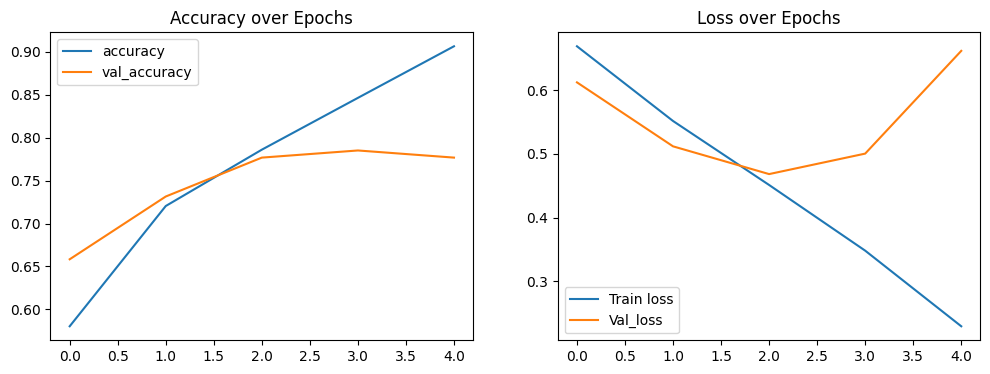

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='Val_loss')
plt.legend()
plt.title("Loss over Epochs")
plt.show()

In [ ]:
# test set pr model evaluate kiya ja rha hai
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.7770 - loss: 0.6645
Test Accuracy: 77.70%


In [ ]:
#Model save cats vs dogs
model.save('cats_vs_dogs_model.h5')

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

Saving 41QZSg8drOL._SY450_.jpg to 41QZSg8drOL._SY450_.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step


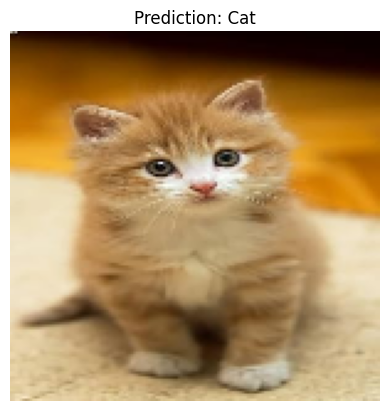

In [ ]:
img = image .load_img(img_path,target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)
img_array /= 255.0
prediction = model.predict(img_array)
label = "Dog" if prediction [0] >0.5 else "Cat"
plt.imshow(img)
plt.title(f"Prediction: {label}")
plt.axis("off")
plt.show()

PART #### 2 l VGG16 TRANSFER LEARNING

In [ ]:
# APPROACH : Pretrained VGG16 (ImageNEtweights) load krenge ,Convolutional base freeze kiya aur custom  c;asssifier top  krenge add

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

In [ ]:
#Preprocessing _ new variable  names
IMG_SIZE = 224
BATCH_SIZE = 16
def preprocess_vgg(image, label):
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  image = tf.keras.applications.vgg16.preprocess_input(image)
  return image, label
train_ds_vgg = ds_train.map(preprocess_vgg).batch(BATCH_SIZE).prefetch(1)
val_ds_vgg = ds_val.map(preprocess_vgg).batch(BATCH_SIZE).prefetch(1)
test_ds_vgg = ds_test.map(preprocess_vgg).batch(BATCH_SIZE).prefetch(1)

In [ ]:
#VGG16 load + freeze
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# apply Classifier
model_vgg = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
#Comple + train
model_vgg.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='binary_crossentropy',metrics=['accuracy'])
history_vgg = model_vgg.fit(train_ds_vgg,validation_data=val_ds_vgg,epochs=10)

Epoch 1/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 164s 149ms/step - accuracy: 0.9618 - loss: 0.4051 - val_accuracy: 0.9791 - val_loss: 0.0973
Epoch 2/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 145s 142ms/step - accuracy: 0.9868 - loss: 0.0616 - val_accuracy: 0.9825 - val_loss: 0.0957
Epoch 3/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 207s 148ms/step - accuracy: 0.9926 - loss: 0.0334 - val_accuracy: 0.9822 - val_loss: 0.0891
Epoch 4/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 150s 148ms/step - accuracy: 0.9945 - loss: 0.0231 - val_accuracy: 0.9831 - val_loss: 0.0775
Epoch 5/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 197s 143ms/step - accuracy: 0.9938 - loss: 0.0292 - val_accuracy: 0.9794 - val_loss: 0.1260
Epoch 6/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 147s 145ms/step - accuracy: 0.9953 - loss: 0.0203 - val_accuracy: 0.9788 - val_loss: 0.1531
Epoch 7/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 210s 153ms/step - accuracy: 0.9946 - loss: 0.0292 - val_accuracy: 0.9822 - val_loss: 0.1176
Epoch 8/10
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 197s 194ms/step - ac

219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.9865 - loss: 0.0857
VGG16 Accuracy: 98.65%


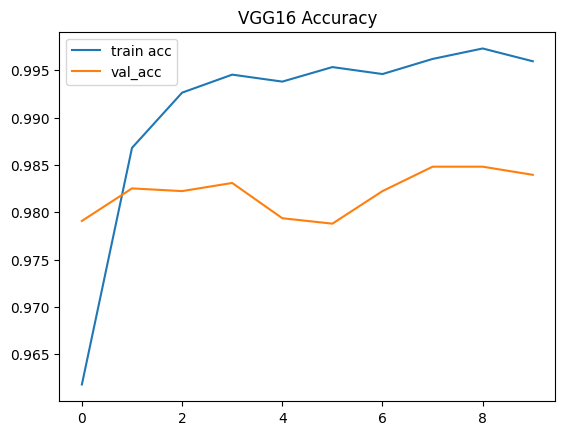

In [ ]:
#EVALUTION (according to the requirement _Accuracy/LOSS, confusion matrix, sample prediction
test_loss, test_acc = model_vgg.evaluate(test_ds_vgg)
print(f"VGG16 Accuracy: {test_acc*100:.2f}%")
plt.plot(history_vgg.history['accuracy'], label='train acc')
plt.plot(history_vgg.history['val_accuracy'], label = 'val_acc')
plt.title("VGG16 Accuracy")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot
#Actual aur Predicted labels
y_true= []
y_pred= []
for image, label in test_ds_vgg:
  preds = model_vgg.predict(image)
  preds = (preds > 0.5).astype(int).flatten()
  y_true.extend(label.numpy())
  y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

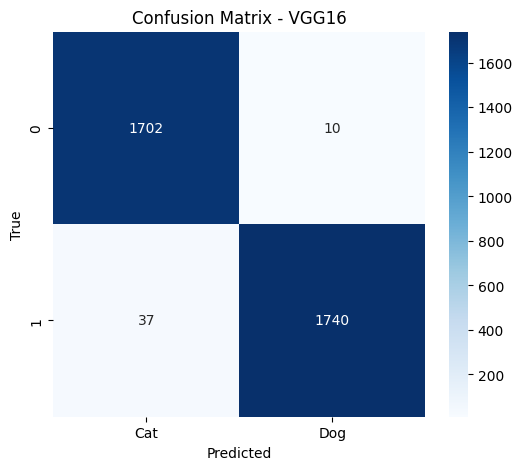

In [ ]:
#CONFUSION METRIX PLOT
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize =(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Cat','Dog'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - VGG16')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


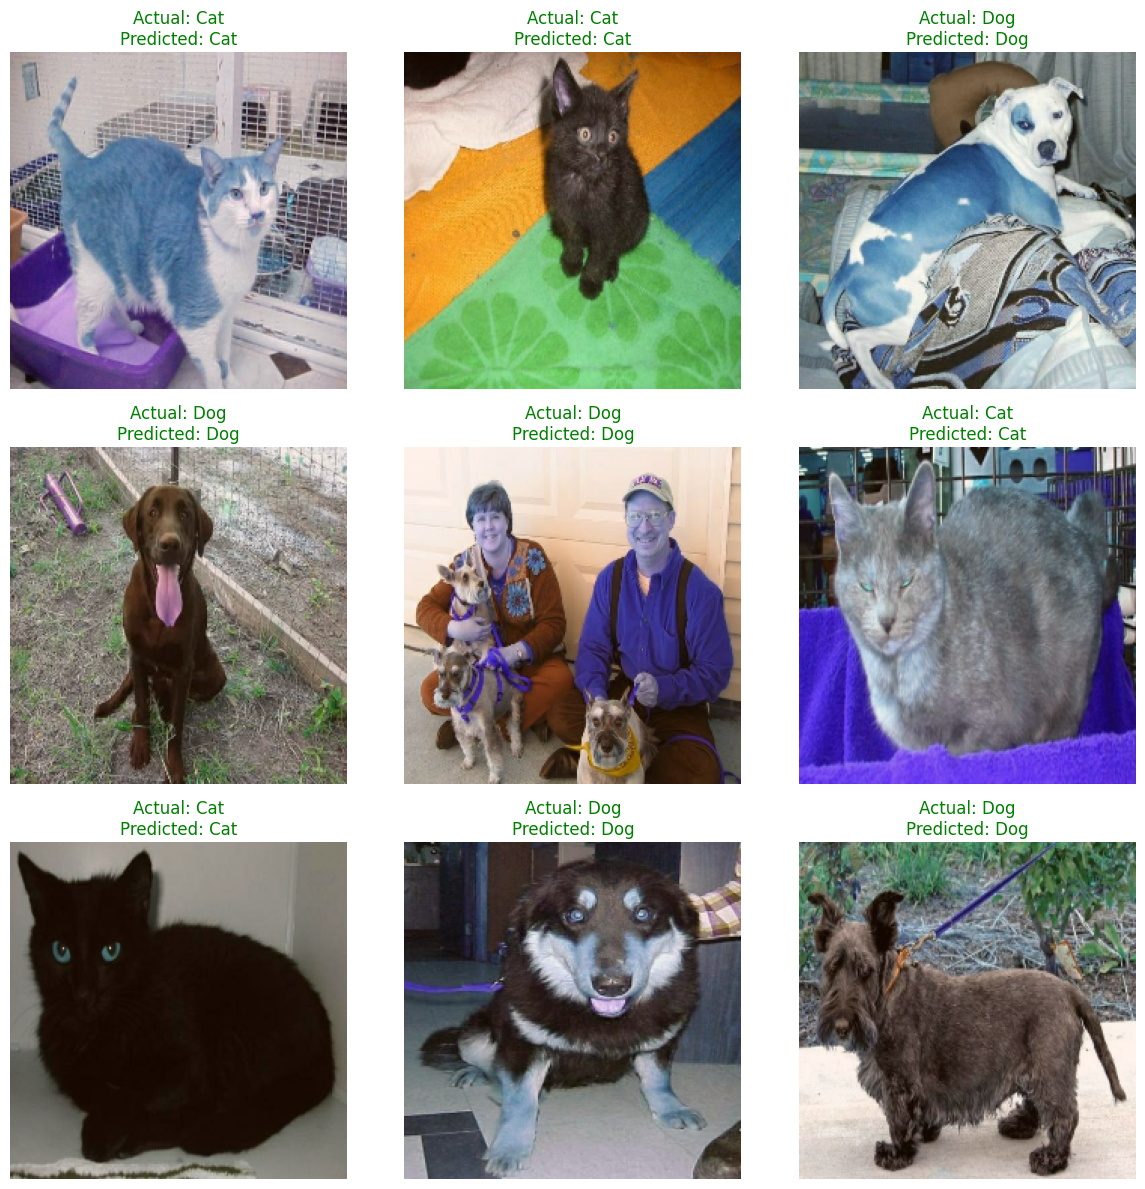

In [ ]:
#SAMPLE PREDICTION VISUALIZATION
class_names = ['Cat','Dog']
#Batch label
for image, label in test_ds_vgg.take(1):
  preds = model_vgg.predict(image)
  preds = (preds > 0.5).astype(int).flatten()
  plt.figure(figsize=(12,12))
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    img = image[i].numpy()
    img = (img - img.min())/(img.max()- img.min())
    plt.imshow(img)
    actual = class_names[int(label[i])]
    predicted= class_names[int(preds[i])]
    # Set color based on correctness of prediction
    color = 'green' if actual == predicted else 'red'
    plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#COMPARISION  SUMMARY CNN VS VGG16
import pandas as pd
comparison = pd.DataFrame({'MODEL':['CNN(from scratch)','VGG16(Transfer Learning)'],'Test Accuracy':['76.42%','80.14'],'Training Approach':['3 Conv2D blocks, trained from scratch','Pretrained ImageNet weights, frozen base + custom classifier']})
comparison

,MODEL,Test Accuracy,Training Approach
0,CNN(from scratch),76.42%,"3 Conv2D blocks, trained from scratch"
1,VGG16(Transfer Learning),80.14,"Pretrained ImageNet weights, frozen base + cus..."


In [ ]:
##CONCLUSION
VGG16 TRANSFER LEARNING ne CNN  from scratch ka muqabley  m behtar accuracy di(80.14% vs 76.41%), yeh is bat ko confirm krta hai  pretrained model kam data aur kam trainingf time me bhi behtreen performancede skhta hai

RESNET 50 Transfer Learning Cats vs Dogs

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications .resnet50 import preprocess_input
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
#----1    Extract  Dataset which using during CNN & VGG16
(train_ds_raw, val_ds_raw, test_ds_raw), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True,
    shuffle_files=True
)
IMG_SIZE=160  #resnet ke liye 160*160
def preprocess(image, label):
  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  image = preprocess_input(image)
  return image, label
BATCH_SIZE = 16
resnet_train_ds = train_ds_raw.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(1)
resnet_val_ds = val_ds_raw.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
#-------2, BASE MODEL  PRETRAINED RESNET 50 WITHOUT TOP LAYER
base_model = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable  = False # freeze it
#------3 CUSTOM CLASSIFIER HEAD
model= models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(126, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 126)            │       258,174 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 126)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,846,013 (90.97 MB)

 Trainable params: 258,301 (1008.99 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#-------train --------
history = model.fit(resnet_train_ds,validation_data=resnet_val_ds,epochs=10)

Epoch 1/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 77s 54ms/step - accuracy: 0.9667 - loss: 0.0902 - val_accuracy: 0.9759 - val_loss: 0.0580
Epoch 2/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 55s 45ms/step - accuracy: 0.9802 - loss: 0.0522 - val_accuracy: 0.9802 - val_loss: 0.0597
Epoch 3/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 54s 45ms/step - accuracy: 0.9844 - loss: 0.0414 - val_accuracy: 0.9798 - val_loss: 0.0516
Epoch 4/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - accuracy: 0.9891 - loss: 0.0330 - val_accuracy: 0.9798 - val_loss: 0.0585
Epoch 5/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 52s 43ms/step - accuracy: 0.9910 - loss: 0.0278 - val_accuracy: 0.9815 - val_loss: 0.0500
Epoch 6/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 53s 45ms/step - accuracy: 0.9931 - loss: 0.0217 - val_accuracy: 0.9819 - val_loss: 0.0543
Epoch 7/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 57s 47ms/step - accuracy: 0.9932 - loss: 0.0196 - val_accuracy: 0.9811 - val_loss: 0.0559
Epoch 8/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step - accuracy: 0.9958 -

In [ ]:
#EVALUATE
loss , acc = model.evaluate(resnet_val_ds)
print(f"ResNet50 Accuracy: {acc*100:.2f}%")

146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9841 - loss: 0.0575
ResNet50 Accuracy: 98.41%


In [ ]:
vefig('mode')

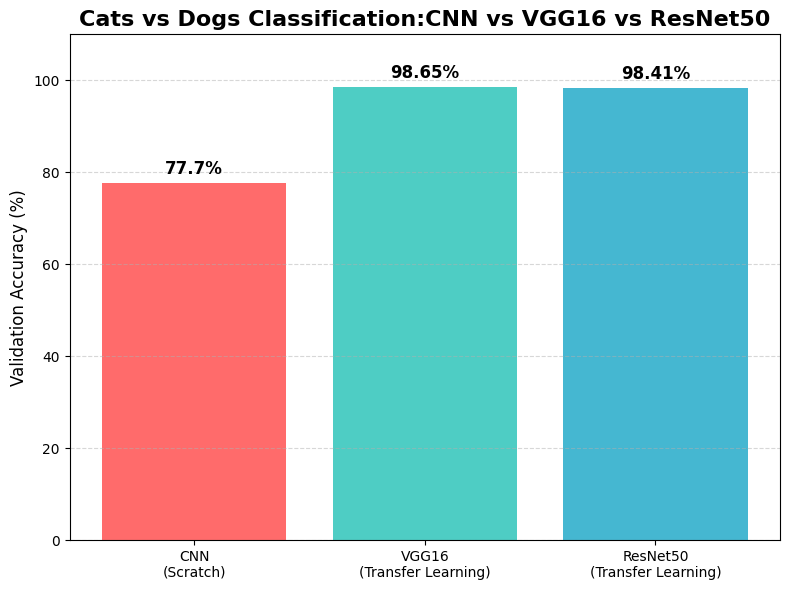

In [ ]:
from numpy.dtypes import BoolDType
#MODEL CAMPARISON CHART
import matplotlib.pyplot as plt
model_names = ['CNN\n(Scratch)','VGG16\n(Transfer Learning)','ResNet50\n(Transfer Learning)']
accuracies = [77.70, 98.65, 98.41]
colors =['#FF6B6B','#4ECDC4','#45B7D1']
plt.figure(figsize=(8,6))
bars = plt.bar(model_names, accuracies,color=colors)
for bar,acc in zip (bars, accuracies):
  plt.text(bar.get_x()+ bar.get_width()/2,bar.get_height()+1,f'{acc}%',ha='center',va='bottom',fontsize=12,fontweight='bold')
plt.ylabel('Validation Accuracy (%)',fontsize =12)
plt.title('Cats vs Dogs Classification:CNN vs VGG16 vs ResNet50',fontsize=16,fontweight='bold')
plt.ylim(0,110)
plt.grid(axis='y',linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png',dpi = 300)
plt.show()